In [1]:
import pandas as pd

In [2]:
BASE_MODELS = [
    "RandomForestClassifier",
    "SVC",
    "LogisticRegression",
    "DecisionTreeClassifier"
]

DATASETS = ["electricity", 
            "rialto",
            "powersupply", 
            "airlines"
            ]

In [ ]:
df = pd.concat(
    [pd.read_csv(f"../time_elapsed/basemodel: {model}  - dataset: {ds} - with_drift_metrics").assign(dataset=ds)
        for model in BASE_MODELS for ds in DATASETS
     ]
)

df_scoring = pd.concat([pd.read_csv(f"../time_elapsed_scoring/basemodel: {model}  - dataset: {ds} - with_drift_metrics").assign(dataset=ds)
        for model in BASE_MODELS for ds in DATASETS
     ])
df = pd.concat([df,df_scoring],axis=1)
df.drop(columns=["Unnamed: 0"],inplace=True)
print(df.head())

<class 'pandas.core.frame.DataFrame'> <class 'list'>
   StatsMFesExtractor  DBSCANMfesExtractor  KmeansMfesExtractor  \
0           29.041542             3.402400           188.499315   
0          163.250537             6.574070           360.642117   
0           39.908492             2.323447           115.346206   
0          214.473172            24.606724          1449.110001   
0           30.633579             3.551392           190.338071   

   PsiCalculator  DomainClassifier     OmvPht  SqsiCalculator  Udetector  \
0       5.560155        128.031762   0.412241        8.946132   4.845032   
0      11.321120        266.731877  16.437937       59.743473  96.182705   
0       2.883129         83.341131  26.613400       30.886790  61.344354   
0       8.288434        291.900273   0.624538       18.294563   6.351310   
0       5.604661        124.178537   0.411995        8.097547   4.379324   

   KSWINDetector  BhattacharyyaDetector  HellingerDistanceDetector  \
0     479.491962 

Dataset: airlines
KSWINDetector                0.707614
KmeansMfesExtractor          0.196479
DomainClassifier             0.046190
JensenShanonDetector         0.021635
StatsMFesExtractor           0.011440
EMDDetector                  0.003538
EnergyDistanceDetector       0.003517
SqsiCalculator               0.002445
DBSCANMfesExtractor          0.002332
BhattacharyyaDetector        0.001422
HellingerDistanceDetector    0.001335
PsiCalculator                0.001139
Udetector                    0.000828
OmvPht                       0.000086
Name: airlines, dtype: float64
------------------------------
Dataset: electricity
KSWINDetector                0.483333
KmeansMfesExtractor          0.188681
JensenShanonDetector         0.135178
DomainClassifier             0.126378
StatsMFesExtractor           0.029944
SqsiCalculator               0.008594
PsiCalculator                0.005547
Udetector                    0.004705
BhattacharyyaDetector        0.004503
HellingerDistanceDetector

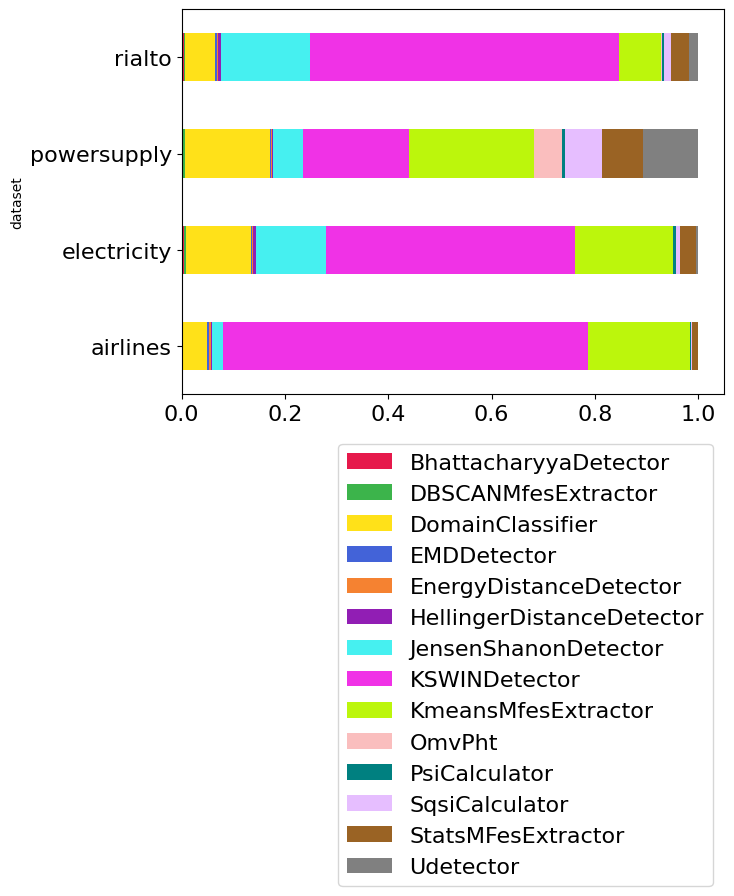

In [4]:
COLORS = [
    "#e6194b", # red
    "#3cb44b", # green
    "#ffe119", # yellow
    "#4363d8", # blue
    "#f58231", # orange
    "#911eb4", # purple
    "#46f0f0", # cyan
    "#f032e6", # magenta
    "#bcf60c", # lime
    "#fabebe", # pink
    "#008080", # teal
    "#e6beff", # lavender
    "#9a6324", # brown
    "#808080", # grey
]
grouped_df = df.groupby("dataset")
grouped_df = grouped_df.mean()

grouped_df = grouped_df.reindex(sorted(grouped_df.columns), axis=1)
grouped_df = grouped_df.div(grouped_df.sum(axis=1), axis=0)
for dataset, row in grouped_df.iterrows():
    print(f"Dataset: {dataset}")
    print(row.sort_values(ascending=False))
    print("-" * 30)
grouped_df.plot.barh(figsize=(7, 5), color=COLORS,fontsize=16, stacked=True).legend(loc='best', prop={'size': 16}, bbox_to_anchor=(1, -0.1))

In [5]:
compare = pd.DataFrame()
compare["total"] =  grouped_df.sum(1)
compare["without_drift"] = grouped_df["DBSCANMfesExtractor"]+grouped_df["KmeansMfesExtractor"]+grouped_df["StatsMFesExtractor"]
compare["with_drift"] =compare["total"]-compare["without_drift"]
compare

,total,without_drift,with_drift
dataset,,,
airlines,1.0,0.210252,0.789748
electricity,1.0,0.222099,0.777901
powersupply,1.0,0.326011,0.673989
rialto,1.0,0.118269,0.881731


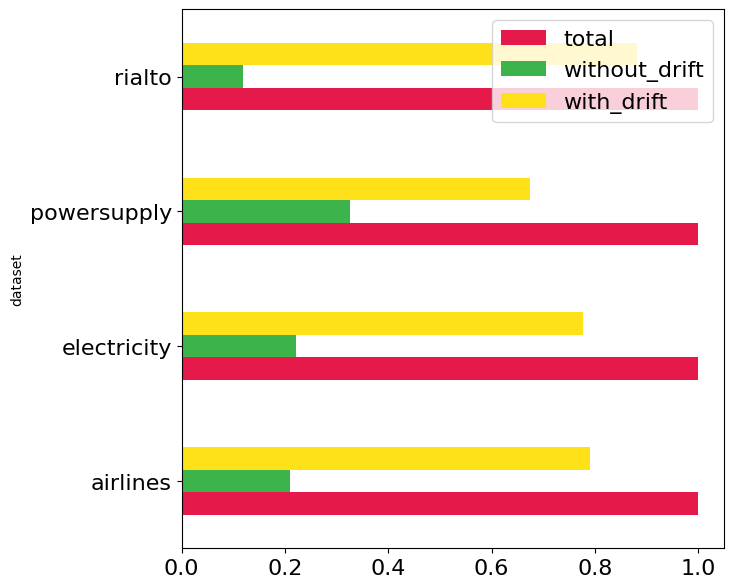

In [6]:

compare.plot.barh(figsize=(7,7), fontsize=16, color=COLORS).legend(loc='best', prop={'size': 16})

Index(['KSWINDetector', 'KmeansMfesExtractor', 'DomainClassifier',
       'JensenShanonDetector', 'StatsMFesExtractor', 'Udetector',
       'SqsiCalculator', 'OmvPht', 'PsiCalculator', 'BhattacharyyaDetector',
       'HellingerDistanceDetector', 'DBSCANMfesExtractor', 'EMDDetector',
       'EnergyDistanceDetector'],
      dtype='object')


/tmp/ipykernel_41320/2736195353.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  porcent.plot.barh(figsize=(7, 5), color=COLORS,fontsize=16, stacked=True).legend(loc='best', prop={'size': 16}, bbox_to_anchor=(1, -0.1))


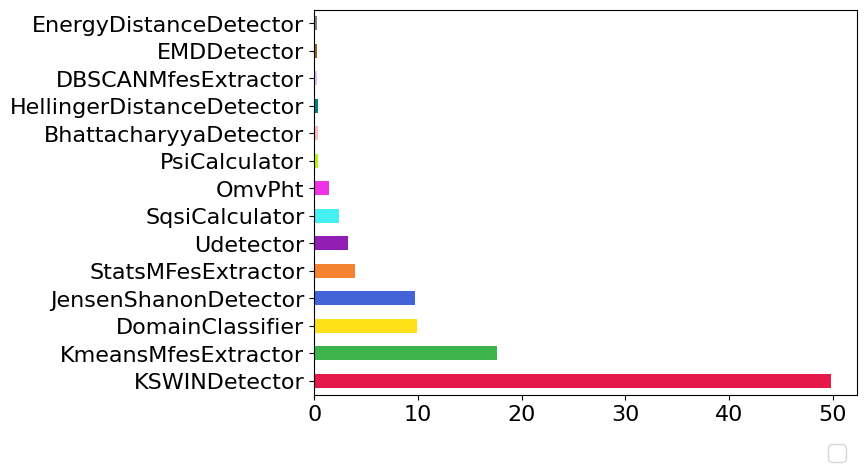

In [7]:
x = grouped_df.columns
y = grouped_df.mean()
porcent = 100.*y/y.sum()
labels = ['{0} - {1:1.1f} %'.format(i,j) for i,j in zip(x, porcent)]
item_order = porcent.sort_values(ascending=False).index
print(item_order)
porcent= porcent[item_order]
porcent.plot.barh(figsize=(7, 5), color=COLORS,fontsize=16, stacked=True).legend(loc='best', prop={'size': 16}, bbox_to_anchor=(1, -0.1))

In [8]:
%store -r all_imps
all_imps = all_imps[["mfe_type", "importance"]].groupby("mfe_type").sum()

In [9]:
print(all_imps)
all_imps["importance"]= all_imps["importance"]*100

                      importance
mfe_type                        
Bhattacharyya           0.034535
ClusteringMetrics       0.017645
DomainClassifier        0.003184
EMD                     0.035614
Energy                  0.027952
Hellinger               0.033456
Jensen-Shannon          0.033941
KSWIN                   0.001727
MiscellaneousMetrics    0.001997
OmvPht                  0.078189
PsiCalculator           0.028491
ScoringMetrics          0.029247
SqsiCalculator          0.015810
StatsMetrics            0.643697
Udetector               0.014515


In [10]:

DRIFT_METRICS_DICT = {
    "KSWINDetector": "KSWIN",
    "JensenShanonDetector": "Jensen-Shannon",
    'StatsMFesExtractor': 'StatsMetrics',
    'BhattacharyyaDetector': "Bhattacharyya",
    "HellingerDistanceDetector": "Hellinger",
    "EMDDetector": "EMD",
    "EnergyDistanceDetector": "Energy"
}

porcent["ClusteringMetrics"] = porcent["KmeansMfesExtractor"]+porcent["DBSCANMfesExtractor"]
porcent.rename(DRIFT_METRICS_DICT,inplace=True)
porcent

KSWIN                  49.837424
KmeansMfesExtractor    17.677424
DomainClassifier        9.888067
Jensen-Shannon          9.691869
StatsMetrics            3.930091
Udetector               3.230594
SqsiCalculator          2.419341
OmvPht                  1.439411
PsiCalculator           0.376690
Bhattacharyya           0.334543
Hellinger               0.324557
DBSCANMfesExtractor     0.308247
EMD                     0.271789
Energy                  0.269954
ClusteringMetrics      17.985671
dtype: float64

In [11]:
df_porcent = porcent.to_frame().T
print(df_porcent)

       KSWIN  KmeansMfesExtractor  DomainClassifier  Jensen-Shannon  \
0  49.837424            17.677424          9.888067        9.691869   

   StatsMetrics  Udetector  SqsiCalculator    OmvPht  PsiCalculator  \
0      3.930091   3.230594        2.419341  1.439411        0.37669   

   Bhattacharyya  Hellinger  DBSCANMfesExtractor       EMD    Energy  \
0       0.334543   0.324557             0.308247  0.271789  0.269954   

   ClusteringMetrics  
0          17.985671  


In [12]:
all_imps = all_imps.T
all_imps.rename(columns={'Jensen-Shannon ':'Jensen-Shannon'},inplace=True)
print(all_imps.columns)

Index(['Bhattacharyya', 'ClusteringMetrics', 'DomainClassifier', 'EMD',
       'Energy', 'Hellinger', 'Jensen-Shannon', 'KSWIN',
       'MiscellaneousMetrics', 'OmvPht', 'PsiCalculator', 'ScoringMetrics',
       'SqsiCalculator', 'StatsMetrics', 'Udetector'],
      dtype='object', name='mfe_type')


In [13]:
res = pd.concat([df_porcent, all_imps], axis=0)
res
print(res.columns)

Index(['KSWIN', 'KmeansMfesExtractor', 'DomainClassifier', 'Jensen-Shannon',
       'StatsMetrics', 'Udetector', 'SqsiCalculator', 'OmvPht',
       'PsiCalculator', 'Bhattacharyya', 'Hellinger', 'DBSCANMfesExtractor',
       'EMD', 'Energy', 'ClusteringMetrics', 'MiscellaneousMetrics',
       'ScoringMetrics'],
      dtype='object')


In [14]:
res.drop(columns=["KmeansMfesExtractor","DBSCANMfesExtractor"],inplace=True)

In [15]:
res

,KSWIN,DomainClassifier,Jensen-Shannon,StatsMetrics,Udetector,SqsiCalculator,OmvPht,PsiCalculator,Bhattacharyya,Hellinger,EMD,Energy,ClusteringMetrics,MiscellaneousMetrics,ScoringMetrics
0,49.837424,9.888067,9.691869,3.930091,3.230594,2.419341,1.439411,0.376690,0.334543,0.324557,0.271789,0.269954,17.985671,NaN,NaN
importance,0.172674,0.318368,3.394129,64.369739,1.451543,1.581049,7.818908,2.849126,3.453486,3.345564,3.561407,2.795165,1.764515,0.199655,2.924671


In [16]:
res = res.T

In [ ]:
res.rename(columns={0: "time"},inplace=True)
res.sort_values(by=["importance"],ascending=False,inplace=True)

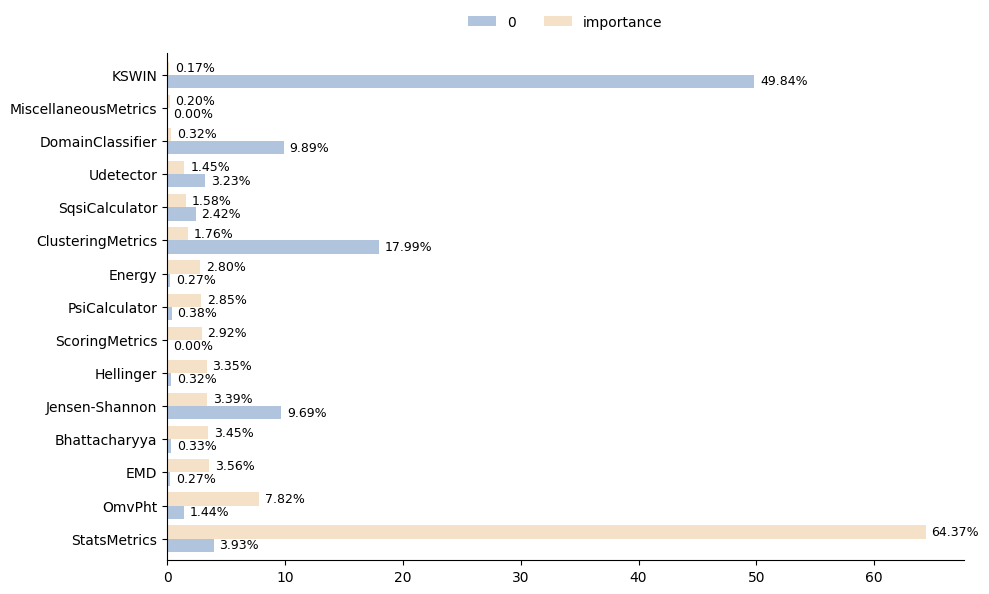

In [26]:

ax = res.plot(
    kind='barh', 
    figsize=(10, 6), 
    color=['#B0C4DE', '#F5E1C8'],
    width=0.8
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=2, frameon=False)

for p in ax.patches:
    ax.annotate(f"{p.get_width():.2f}%", 
                (p.get_width() + 0.5, p.get_y() + 0.1), 
                fontsize=9)
import matplotlib.pyplot as plt
plt.tight_layout()
plt.show()

In [24]:
res

,0,importance
KSWIN,49.837424,0.172674
DomainClassifier,9.888067,0.318368
Jensen-Shannon,9.691869,3.394129
StatsMetrics,3.930091,64.369739
Udetector,3.230594,1.451543
SqsiCalculator,2.419341,1.581049
OmvPht,1.439411,7.818908
PsiCalculator,0.376690,2.849126
Bhattacharyya,0.334543,3.453486
Hellinger,0.324557,3.345564
